# Feature Engineering – Fraud Detection (E-commerce)

## Objective
This notebook focuses on creating meaningful features from the raw e-commerce fraud dataset.
Feature engineering helps the model better understand user behavior, time patterns, and fraud signals.

We will:
- Create time-based features
- Create transaction frequency features
- Integrate geolocation (country)
- Encode categorical variables
- Scale numerical features
- Save the final processed dataset for modeling


In [1]:
import os
import sys

# Hard-code your real project root (copy-paste from your PS prompt)
project_root = r"C:\Users\Y\Downloads\fraud-detection"

# Change to it
os.chdir(project_root)
print("Now changed to:", os.getcwd())

# Quick check: list some expected folders/files
print("Contents of current dir:", os.listdir('.')[:10])  # should show 'data', 'notebooks', 'src', etc.
print("data folder exists?", os.path.isdir("data"))
print("raw folder exists?", os.path.isdir("data/raw"))

# Verify the exact files
print("Fraud_Data.csv exists?", os.path.exists("data/raw/Fraud_Data.csv"))
print("Full path:", os.path.abspath("data/raw/Fraud_Data.csv"))

print("IpAddress_to_Country.csv exists?", os.path.exists("data/raw/IpAddress_to_Country.csv"))
print("Full path:", os.path.abspath("data/raw/IpAddress_to_Country.csv"))

# Make src importable
if project_root not in sys.path:
    sys.path.insert(0, project_root)

Now changed to: C:\Users\Y\Downloads\fraud-detection
Contents of current dir: ['.git', '.github', '.gitignore', '.pytest_cache', '.qodo', '.vscode', 'data', 'figures', 'models', 'notebooks']
data folder exists? True
raw folder exists? True
Fraud_Data.csv exists? True
Full path: C:\Users\Y\Downloads\fraud-detection\data\raw\Fraud_Data.csv
IpAddress_to_Country.csv exists? True
Full path: C:\Users\Y\Downloads\fraud-detection\data\raw\IpAddress_to_Country.csv


In [2]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from src.preprocessing import preprocess_fraud_full

sns.set(style="whitegrid")

# Task 1: Feature Engineering - E-Commerce Fraud Data
Objective: Geolocation integration, time/velocity features, transformation, and fraud patterns.

In [3]:
from src.preprocessing import preprocess_fraud_full

df = preprocess_fraud_full(save=False)   # or save=False

Removed 0 duplicates
Missing values: 0 (none expected)
Cleaned shape for modeling: (151112, 196)
Final columns: ['age', 'browser_FireFox', 'browser_IE', 'browser_Opera', 'browser_Safari', 'class', 'country_Albania', 'country_Algeria', 'country_Angola', 'country_Antigua and Barbuda', 'country_Argentina', 'country_Armenia', 'country_Australia', 'country_Austria', 'country_Azerbaijan', 'country_Bahamas', 'country_Bahrain', 'country_Bangladesh', 'country_Barbados', 'country_Belarus', 'country_Belgium', 'country_Belize', 'country_Benin', 'country_Bermuda', 'country_Bhutan', 'country_Bolivia', 'country_Bonaire; Sint Eustatius; Saba', 'country_Bosnia and Herzegowina', 'country_Botswana', 'country_Brazil', 'country_British Indian Ocean Territory', 'country_Brunei Darussalam', 'country_Bulgaria', 'country_Burkina Faso', 'country_Burundi', 'country_Cambodia', 'country_Cameroon', 'country_Canada', 'country_Cape Verde', 'country_Cayman Islands', 'country_Chile', 'country_China', 'country_Colombia'

## 1. Geolocation Integration & Fraud Patterns by Country
IP → country mapped, analyzed fraud rate.

In [4]:
print("Shape:", df.shape)
print("Columns include 'country'?", 'country' in df.columns)          # should be False now (because one-hot happened)
print("But country_* dummies exist?", any('country_' in col for col in df.columns))

# Look at original country distribution before encoding
# If you want raw countries → add print before transform_features in your function
print("\nTop countries (from dummies):")
country_cols = [col for col in df.columns if col.startswith('country_')]
if country_cols:
    top = df[country_cols].sum().sort_values(ascending=False).head(10)
    print(top / len(df) * 100)   # approximate %

Shape: (151112, 196)
Columns include 'country'? False
But country_* dummies exist? True

Top countries (from dummies):
country_United States        38.414553
country_Unknown              14.536238
country_China                 7.966277
country_Japan                 4.834825
country_United Kingdom        2.971306
country_Korea Republic of     2.754249
country_Germany               2.412780
country_France                2.091826
country_Canada                1.968738
country_Brazil                1.959474
dtype: float64


C:\Users\Y\AppData\Local\Temp\ipykernel_4544\2885603357.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_fraud.values, y=top_fraud.index, palette="Reds_r")


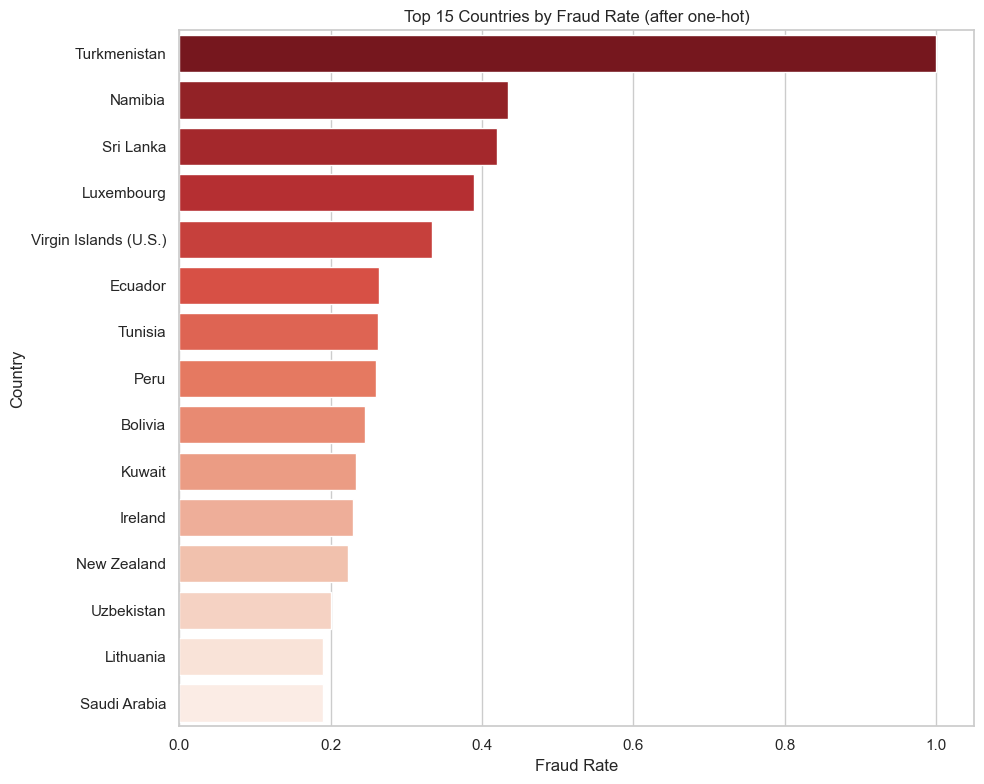

Top fraud rates:
 Turkmenistan             1.000000
Namibia                  0.434783
Sri Lanka                0.419355
Luxembourg               0.388889
Virgin Islands (U.S.)    0.333333
Ecuador                  0.264151
Tunisia                  0.262712
Peru                     0.260504
Bolivia                  0.245283
Kuwait                   0.233333
Ireland                  0.229167
New Zealand              0.223022
Uzbekistan               0.200000
Lithuania                0.189474
Saudi Arabia             0.189394
dtype: float64


In [21]:
country_cols = [col for col in df.columns if col.startswith('country_')]
if country_cols:
    fraud_rates = {}
    for col in country_cols:
        country_name = col.replace('country_', '')
        mask = df[col] == 1
        if mask.sum() > 0:
            fraud_rates[country_name] = df.loc[mask, 'class'].mean()

    top_fraud = pd.Series(fraud_rates).sort_values(ascending=False).head(15)

    plt.figure(figsize=(10, 8))
    sns.barplot(x=top_fraud.values, y=top_fraud.index, palette="Reds_r")
    plt.title("Top 15 Countries by Fraud Rate (after one-hot)")
    plt.xlabel("Fraud Rate")
    plt.ylabel("Country")
    plt.tight_layout()
    plt.show()

    print("Top fraud rates:\n", top_fraud)
else:
    print("No country columns found — run preprocessing first")

## 2. Time-Based & Velocity Features
- time_since_signup_hours
- hour_of_day / day_of_week
- tx_per_user / tx_per_device

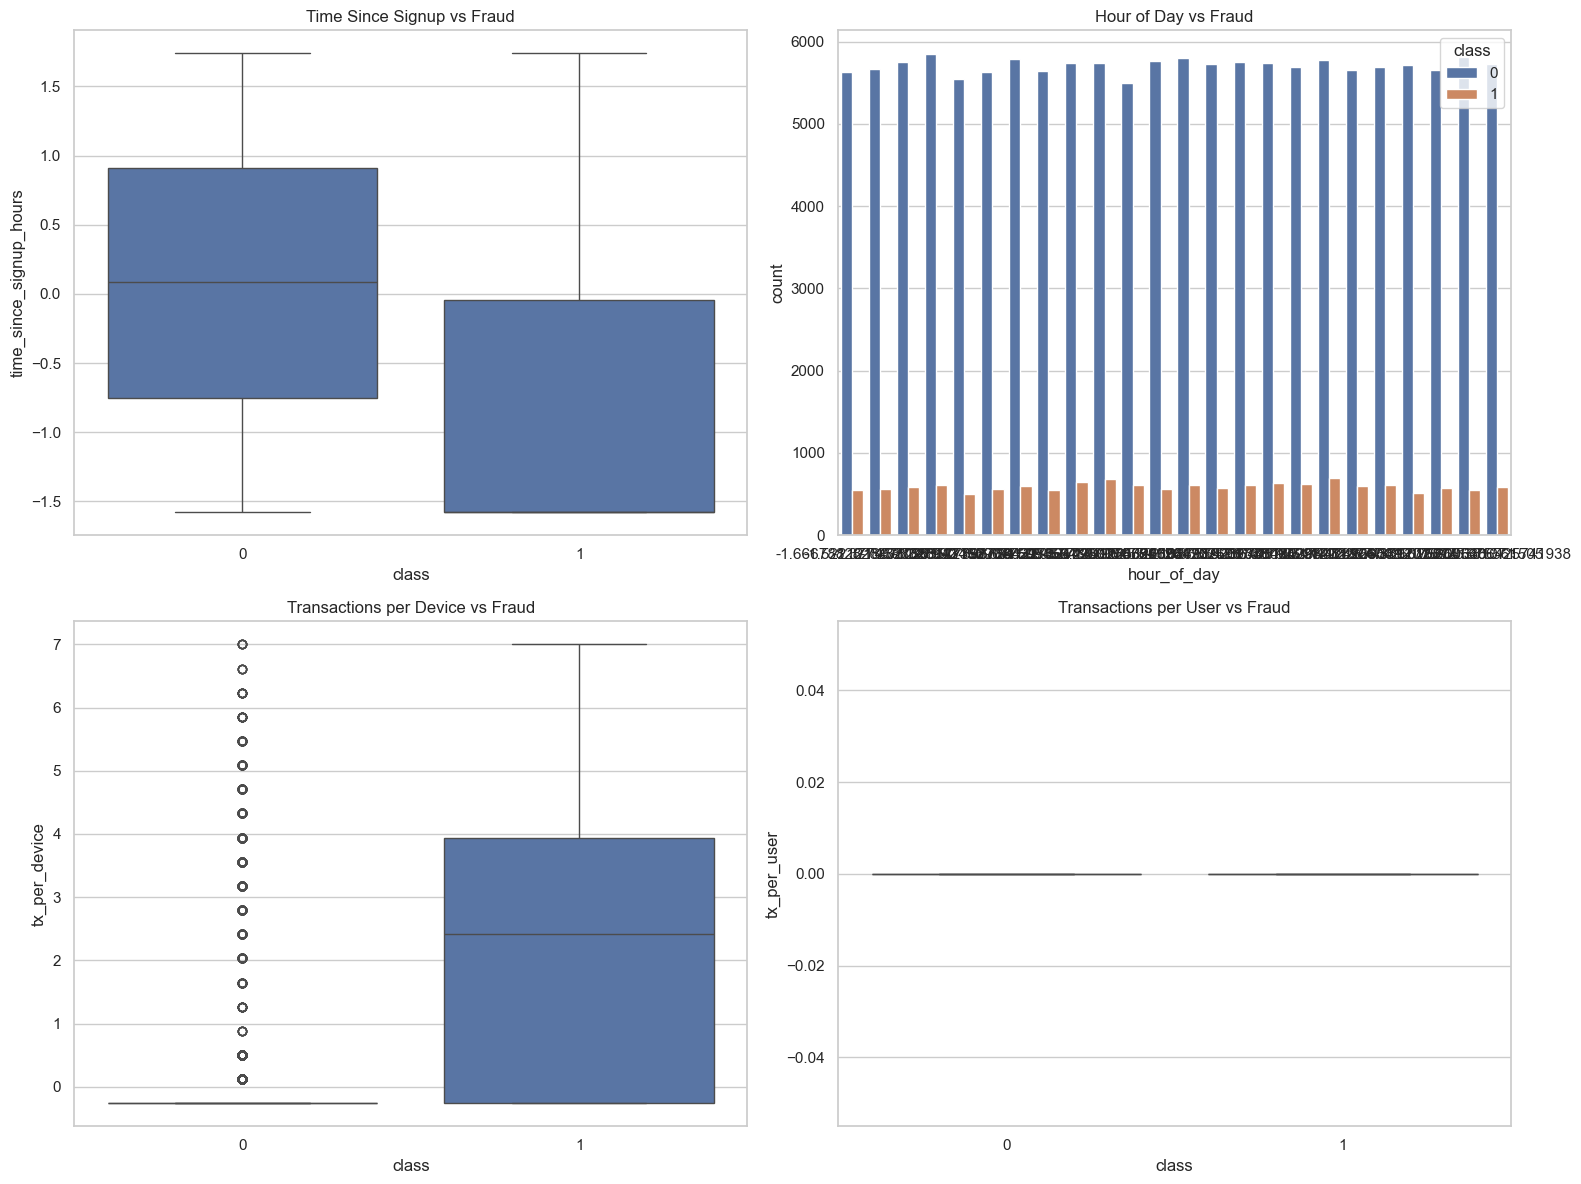

In [5]:
fig, ax = plt.subplots(2, 2, figsize=(16,12))
sns.boxplot(x="class", y="time_since_signup_hours", data=df, ax=ax[0,0])
ax[0,0].set_title("Time Since Signup vs Fraud")
sns.countplot(x="hour_of_day", hue="class", data=df, ax=ax[0,1])
ax[0,1].set_title("Hour of Day vs Fraud")
sns.boxplot(x="class", y="tx_per_device", data=df, ax=ax[1,0])
ax[1,0].set_title("Transactions per Device vs Fraud")
sns.boxplot(x="class", y="tx_per_user", data=df, ax=ax[1,1])
ax[1,1].set_title("Transactions per User vs Fraud")
plt.tight_layout()
plt.show()

## 3. Data Transformation & Imbalance Handling Strategy
- Numerical: StandardScaler
- Categorical: One-Hot Encoding
- Imbalance: SMOTE applied only on training data in Task 2 (justification: synthesizes realistic minority samples without test leakage; better than undersampling which discards data).
Before/after documented in modeling.